In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✅")

All libraries loaded ✅


In [10]:
# Let's see all the files that were downloaded
print("Files in data/raw/:\n")

raw_path = "../data/raw"
for folder in sorted(os.listdir(raw_path)):
    folder_path = os.path.join(raw_path, folder)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        for f in files:
            filepath = os.path.join(folder_path, f)
            size_kb = os.path.getsize(filepath) / 1024
            print(f"  {folder}/{f}  →  {size_kb:.1f} KB")

Files in data/raw/:

  T1021_RemoteServices/windows-security.log  →  6209.1 KB
  T1055_ProcessInjection/windows-sysmon.log  →  152875.3 KB
  T1110_BruteForce/windows-security.log  →  351.2 KB


In [11]:
# Before anything else, let's see what the raw data looks like
# This shows the first 30 lines of the Brute Force log file

log_path = "../data/raw/T1110_BruteForce/windows-security.log"

print("=== RAW LOG FILE — FIRST 30 LINES ===")
print("This is what a real Windows Security Event log looks like")
print()

with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()

for i, line in enumerate(lines[:30]):
    print(f"{i+1:3}  {line.rstrip()[:120]}")

print()
print(f"Total lines in this file: {len(lines)}")

=== RAW LOG FILE — FIRST 30 LINES ===
This is what a real Windows Security Event log looks like

  1  04/20/2021 08:21:24 PM
  2  LogName=Security
  3  SourceName=Microsoft Windows security auditing.
  4  EventCode=4689
  5  EventType=0
  6  Type=Information
  7  ComputerName=win-host-816.attackrange.local
  8  TaskCategory=Process Termination
  9  OpCode=Info
 10  RecordNumber=1305186
 11  Keywords=Audit Success
 12  Message=A process has exited.
 13  
 14  Subject:
 15  	Security ID:		NT AUTHORITY\SYSTEM
 16  	Account Name:		WIN-HOST-816$
 17  	Account Domain:		ATTACKRANGE
 18  	Logon ID:		0x3E7
 19  
 20  Process Information:
 21  	Process ID:	0x4b4
 22  	Process Name:	C:\Program Files\SplunkUniversalForwarder\bin\splunk-powershell.exe
 23  	Exit Status:	0x1
 24  04/20/2021 08:21:24 PM
 25  LogName=Security
 26  SourceName=Microsoft Windows security auditing.
 27  EventCode=4688
 28  EventType=0
 29  Type=Information
 30  ComputerName=win-host-816.attackrange.local

Total lines in t

In [12]:
# Raw logs are plain text — not useful for ML yet
# We need to EXTRACT specific fields and turn them into a table
# Each row = one event, each column = one feature

def parse_log_file(filepath, technique_label):
    records = []
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
    
    # Split into individual events
    events = re.split(r'\n(?=EventCode=|\d{2}/\d{2}/\d{4}|\d{4}-\d{2}-\d{2})', content)
    
    for event in events:
        if len(event.strip()) < 10:
            continue
        
        record = {}
        record['technique'] = technique_label
        record['raw_length'] = len(event)
        
        # EventCode — the type of Windows event
        ec = re.search(r'EventCode=(\d+)', event)
        record['EventCode'] = int(ec.group(1)) if ec else 0
        
        # ComputerName
        cn = re.search(r'ComputerName=([^\s\n]+)', event)
        record['ComputerName'] = cn.group(1) if cn else 'unknown'
        
        # Account Name
        an = re.search(r'Account Name:\s*([^\n\r]+)', event)
        record['AccountName'] = an.group(1).strip() if an else 'unknown'
        
        # Process Name
        pn = re.search(r'(?:Process Name|New Process Name):\s*([^\n\r]+)', event)
        record['ProcessName'] = pn.group(1).strip() if pn else 'unknown'
        
        # Command Line
        cl = re.search(r'Process Command Line:\s*([^\n\r]+)', event)
        record['CommandLine'] = cl.group(1).strip() if cl else ''
        record['CommandLineLength'] = len(record['CommandLine'])
        
        # Logon Type
        lt = re.search(r'Logon Type:\s*(\d+)', event)
        record['LogonType'] = int(lt.group(1)) if lt else 0
        
        # Failure Reason
        fr = re.search(r'Failure Reason:\s*([^\n\r]+)', event)
        record['FailureReason'] = fr.group(1).strip() if fr else 'none'
        
        # Binary feature flags
        record['IsFailedLogon']    = 1 if record['EventCode'] == 4625 else 0
        record['IsSuccessLogon']   = 1 if record['EventCode'] == 4624 else 0
        record['IsProcessCreation']= 1 if record['EventCode'] == 4688 else 0
        record['IsPrivilegeUse']   = 1 if record['EventCode'] == 4672 else 0
        record['HasCommandLine']   = 1 if record['CommandLineLength'] > 0 else 0
        
        records.append(record)
    
    return pd.DataFrame(records)

# Test on one file
print("Parsing T1110 Brute Force log...")
df_test = parse_log_file(
    "../data/raw/T1110_BruteForce/windows-security.log",
    "T1110"
)
print(f"Result: {df_test.shape[0]} events, {df_test.shape[1]} columns")
print()
df_test.head()

Parsing T1110 Brute Force log...
Result: 536 events, 15 columns



,technique,raw_length,EventCode,ComputerName,AccountName,ProcessName,CommandLine,CommandLineLength,LogonType,FailureReason,IsFailedLogon,IsSuccessLogon,IsProcessCreation,IsPrivilegeUse,HasCommandLine
0,T1110,87,0,unknown,unknown,unknown,,0,0,none,0,0,0,0,0
1,T1110,471,4689,win-host-816.attackrange.local,WIN-HOST-816$,C:\Program Files\SplunkUniversalForwarder\bin\...,,0,0,none,0,0,0,0,0
2,T1110,87,0,unknown,unknown,unknown,,0,0,none,0,0,0,0,0
3,T1110,1923,4688,win-host-816.attackrange.local,WIN-HOST-816$,C:\Program Files\SplunkUniversalForwarder\bin\...,"""C:\Program Files\SplunkUniversalForwarder\bin...",69,0,none,0,0,1,0,1
4,T1110,87,0,unknown,unknown,unknown,,0,0,none,0,0,0,0,0


In [13]:
# Now parse every log file and combine into one big dataset

all_dfs = []

files = [
    ("../data/raw/T1110_BruteForce/windows-security.log",     "T1110"),
    ("../data/raw/T1059_CommandShell/windows-powershell.log",  "T1059"),
    ("../data/raw/T1055_ProcessInjection/windows-sysmon.log",  "T1055"),
    ("../data/raw/T1021_RemoteServices/windows-security.log",  "T1021"),
]

print("Parsing all files...\n")

for filepath, technique in files:
    if os.path.exists(filepath):
        df_temp = parse_log_file(filepath, technique)
        all_dfs.append(df_temp)
        print(f"  ✅ {technique}: {len(df_temp)} events parsed")
    else:
        print(f"  ❌ File not found: {filepath}")

# Combine all into one dataset
df = pd.concat(all_dfs, ignore_index=True)

print()
print(f"Total dataset: {df.shape[0]} events, {df.shape[1]} columns")

Parsing all files...

  ✅ T1110: 536 events parsed
  ❌ File not found: ../data/raw/T1059_CommandShell/windows-powershell.log
  ✅ T1055: 1 events parsed
  ✅ T1021: 10914 events parsed

Total dataset: 11451 events, 15 columns


In [14]:
# Now let's understand what we have

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nTotal events:  {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")

print(f"\nEvents per ATT&CK Technique:")
print(df['technique'].value_counts())

print(f"\nEventCode breakdown:")
print(df['EventCode'].value_counts().head(10))

print(f"\nMissing values:")
print(df.isnull().sum())

DATASET OVERVIEW

Total events:  11451
Total columns: 15

Column names:
  - technique
  - raw_length
  - EventCode
  - ComputerName
  - AccountName
  - ProcessName
  - CommandLine
  - CommandLineLength
  - LogonType
  - FailureReason
  - IsFailedLogon
  - IsSuccessLogon
  - IsProcessCreation
  - IsPrivilegeUse
  - HasCommandLine

Events per ATT&CK Technique:
technique
T1021    10914
T1110      536
T1055        1
Name: count, dtype: int64

EventCode breakdown:
EventCode
0       5726
4624     915
4672     896
4634     739
4907     695
4648     659
4768     528
4769     522
4776     151
4688     133
Name: count, dtype: int64

Missing values:
technique            0
raw_length           0
EventCode            0
ComputerName         0
AccountName          0
ProcessName          0
CommandLine          0
CommandLineLength    0
LogonType            0
FailureReason        0
IsFailedLogon        0
IsSuccessLogon       0
IsProcessCreation    0
IsPrivilegeUse       0
HasCommandLine       0
dtype: i

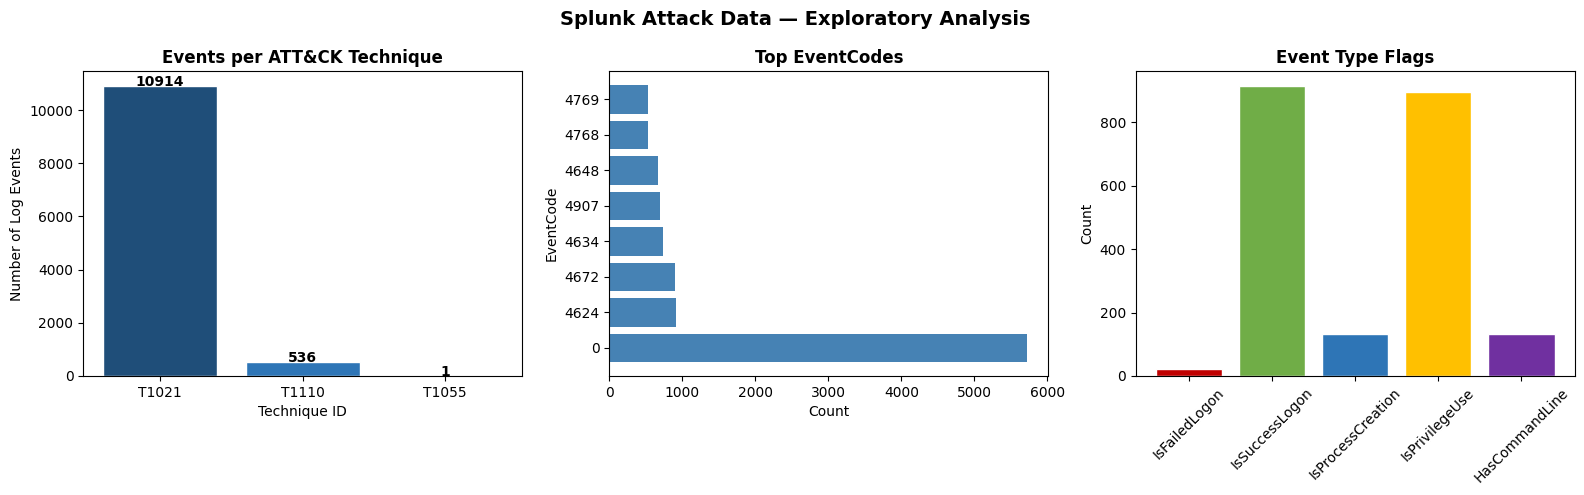

Chart saved to results/01_data_exploration.png ✅


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Splunk Attack Data — Exploratory Analysis', 
             fontsize=14, fontweight='bold')

# Chart 1: Events per technique
counts = df['technique'].value_counts()
colors = ['#1f4e79', '#2e75b6', '#4472c4', '#70ad47']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Events per ATT&CK Technique', fontweight='bold')
axes[0].set_xlabel('Technique ID')
axes[0].set_ylabel('Number of Log Events')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(int(bar.get_height())),
                 ha='center', fontsize=10, fontweight='bold')

# Chart 2: EventCode distribution
ec_counts = df['EventCode'].value_counts().head(8)
axes[1].barh(ec_counts.index.astype(str), ec_counts.values, color='steelblue')
axes[1].set_title('Top EventCodes', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('EventCode')

# Chart 3: Binary feature flags
flags = df[['IsFailedLogon','IsSuccessLogon',
            'IsProcessCreation','IsPrivilegeUse',
            'HasCommandLine']].sum()
flag_colors = ['#c00000','#70ad47','#2e75b6','#ffc000','#7030a0']
axes[2].bar(flags.index, flags.values, color=flag_colors, edgecolor='white')
axes[2].set_title('Event Type Flags', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

os.makedirs("../results", exist_ok=True)
plt.savefig('../results/01_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to results/01_data_exploration.png ✅")

In [16]:
# Save the clean table as a CSV file
# This is what Notebook 02 will load for preprocessing

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/splunk_parsed.csv", index=False)

print("✅ Dataset saved to data/processed/splunk_parsed.csv")
print()
print(f"Shape: {df.shape}")
print()
print("Final summary:")
print(df['technique'].value_counts())
print()

✅ Dataset saved to data/processed/splunk_parsed.csv

Shape: (11451, 15)

Final summary:
technique
T1021    10914
T1110      536
T1055        1
Name: count, dtype: int64

